In [210]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import sys


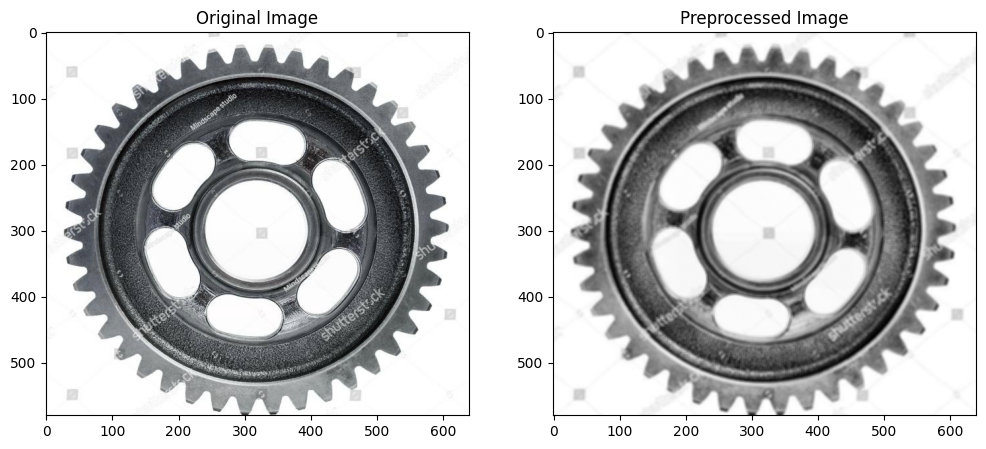

In [211]:
## Image Preprocessing 

# 1. Grayscale Conversion
img = cv2.imread('./data/test/test_56.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2. CLAHE Histogram Equalization
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
equalized = clahe.apply(gray)

# 3. Gaussian Blurring
sigma = 5.0
blurred = cv2.GaussianBlur(equalized, (5, 5), sigma)

# Display the results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(img)
plt.subplot(1, 2, 2)
plt.title('Preprocessed Image')
plt.imshow(blurred, cmap='gray')

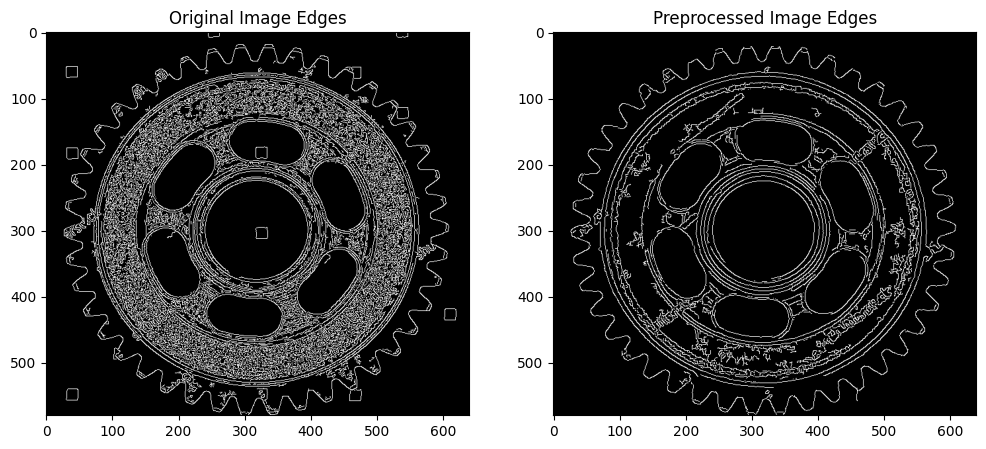

In [212]:
# Edge Detection
original_edges = cv2.Canny(gray, 50, 150)
processed_edges = cv2.Canny(blurred, 50, 150)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Original Image Edges')
plt.imshow(original_edges, cmap='gray')
plt.subplot(1, 2, 2)
plt.title('Preprocessed Image Edges')
plt.imshow(processed_edges, cmap='gray')
plt.show()

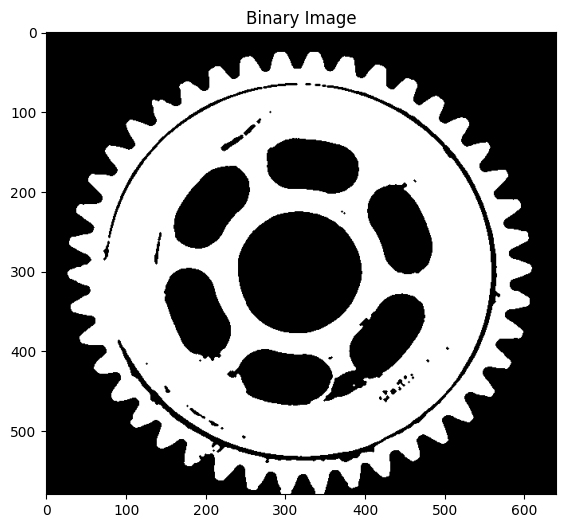

In [213]:
# Binarize and fill the image
from numpy.ma import filled


_, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# If the gear is darker than the background, invert
# (Otsu might give you background=white or gear=white depending on the image)
# Check and flip if needed:
if np.mean(binary[binary > 0]) < 127:
    binary = cv2.bitwise_not(binary)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))

# Closing: fills small holes/gaps inside the gear body
binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=1)

# Opening: removes small isolated blobs outside the gear
binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)

# invert the image since cv2 whants white objects on black background
binary = cv2.bitwise_not(binary)


# show results
plt.figure(figsize=(12, 6))
plt.title('Binary Image')
plt.imshow(binary, cmap='gray')
plt.show()


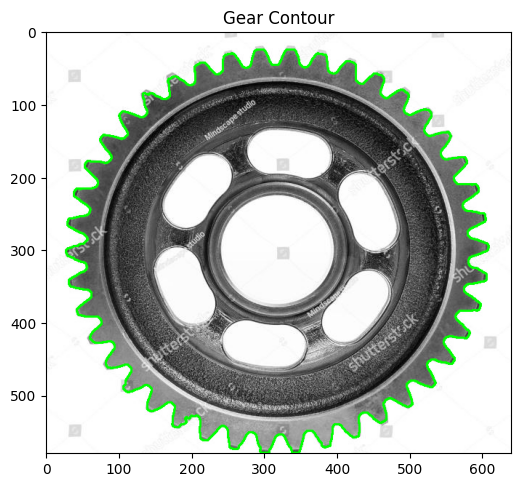

In [214]:
contours, hierarchy = cv2.findContours(
    binary, # binarized and filled image of the gear      
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_NONE
)

gear_contour = max(contours, key=cv2.contourArea)

# show the contour
debug = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)  
cv2.drawContours(debug, [gear_contour], -1, (0, 255, 0), 2)  # green contour
plt.figure(figsize=(6, 6))
plt.title('Gear Contour')
plt.imshow(debug)
plt.show()

Centroid: (317, 299)


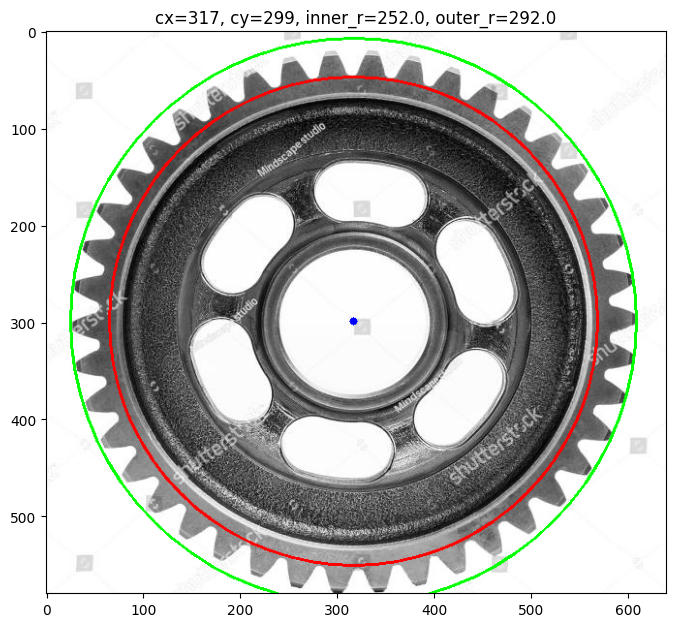

In [215]:
M  = cv2.moments(gear_contour)
cx = int(M['m10'] / M['m00'])
cy = int(M['m01'] / M['m00'])

# Compute all distances from centroid to every contour point
dists = np.array([np.linalg.norm(p[0] - [cx, cy]) for p in gear_contour])

r_mean = dists.mean()
r_std  = dists.std()


outer_r = np.max(dists)
inner_r = np.min(dists)

print(f'Centroid: ({cx}, {cy})')

# Visual check
debug = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
cv2.circle(debug, (cx, cy), int(outer_r), (0, 255, 0), 2)
cv2.circle(debug, (cx, cy), int(inner_r), (0, 0, 255), 2)
cv2.circle(debug, (cx, cy), 4,            (255, 0, 0), -1)

plt.figure(figsize=(8, 8))
plt.title(f'cx={cx}, cy={cy}, inner_r={inner_r:.1f}, outer_r={outer_r:.1f}')
plt.imshow(cv2.cvtColor(debug, cv2.COLOR_BGR2RGB))
plt.gca().set_aspect('equal')   # ← forces square pixels in the plot
plt.show()

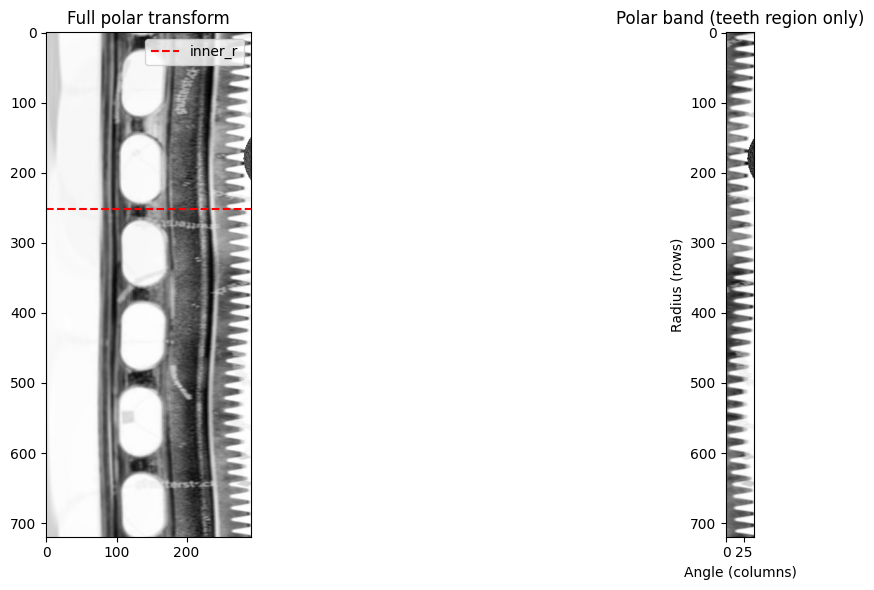

In [216]:
def apply_polar_transform(gray_blurred, cx, cy, inner_r, outer_r):

    center  = (int(cx), int(cy))
    polar_w = int(outer_r)   # columns = radial axis (pixels)
    polar_h = 720            # rows    = angular axis (0° → 360°)

    polar = cv2.warpPolar(
        gray_blurred,
        dsize     = (polar_w, polar_h),  # (cols=radius, rows=angle)
        center    = center,
        maxRadius = int(outer_r),
        flags     = cv2.WARP_POLAR_LINEAR + cv2.INTER_CUBIC
    )

    # crop columns (radial axis) to isolate the annular band
    band_start = int((inner_r / outer_r) * polar_w)
    polar_band = polar[:, band_start:]   # ← columns, not rows

    return polar, polar_band, band_start

polar, polar_band, band_start = apply_polar_transform(
    blurred, cx, cy, inner_r, outer_r
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].set_title("Full polar transform")
axes[0].imshow(polar, cmap='gray')
axes[0].axhline(y=band_start, color='r', linestyle='--', label='inner_r')
axes[0].legend()

axes[1].set_title("Polar band (teeth region only)")
axes[1].imshow(polar_band, cmap='gray')
axes[1].set_xlabel("Angle (columns)")
axes[1].set_ylabel("Radius (rows)")

plt.tight_layout()
plt.show()

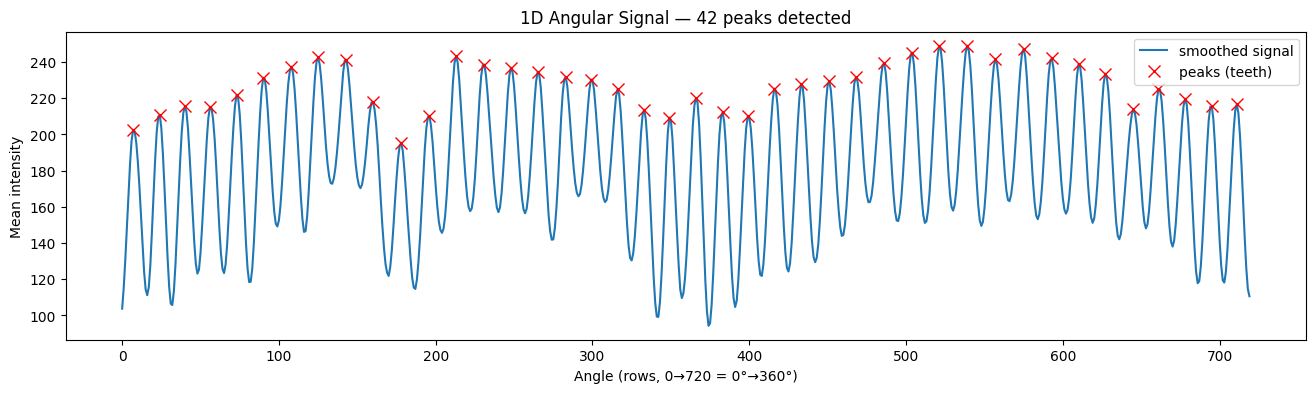

In [217]:
# detect peaks

from scipy.signal import find_peaks, savgol_filter

def detect_teeth_peaks(polar_band, polar_h=720):

    # 1. Collapse the band into a 1D signal by averaging along columns (radial axis)
    signal = np.mean(polar_band, axis=1).astype(np.float32)  # shape: (720,)

    # 2. Smooth the signal to reduce noise
    signal_smooth = savgol_filter(signal, window_length=11, polyorder=3)

    # 3. Detect peaks
    peaks, properties = find_peaks(
        signal_smooth,
        prominence=10,      # minimum peak height above surroundings
        distance=5          # minimum angular distance between peaks (in rows)
    )

    return signal_smooth, peaks

signal, peaks = detect_teeth_peaks(polar_band)

plt.figure(figsize=(16, 4))
plt.title(f"1D Angular Signal — {len(peaks)} peaks detected")
plt.plot(signal, label="smoothed signal")
plt.plot(peaks, signal[peaks], "x", color="red", markersize=8, label="peaks (teeth)")
plt.xlabel("Angle (rows, 0→720 = 0°→360°)")
plt.ylabel("Mean intensity")
plt.legend()
plt.show()

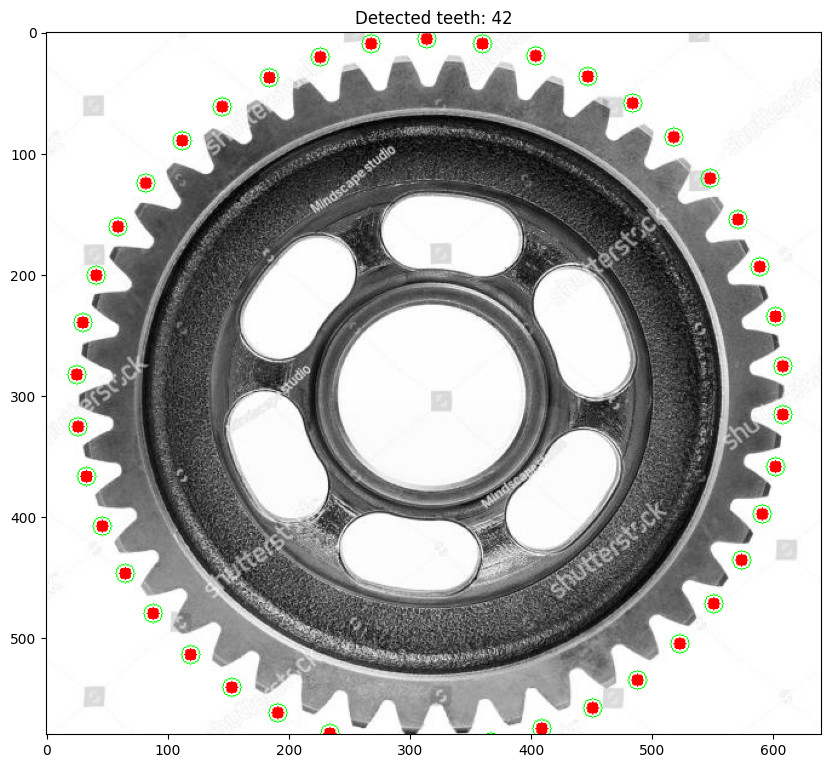

In [218]:
# map the detected peaks in polar space into the original cartesion image coordinates
def backproject_peaks(peaks, cx, cy, outer_r, polar_h=720):
    
    points = []
    
    for peak_row in peaks:
        
        # 1. Convert row index to angle in radians
        angle_rad = (peak_row / polar_h) * 2 * np.pi

        # 2. Compute cartesian coordinates at outer_r (tooth tips)
        x = int(cx + outer_r * np.cos(angle_rad))
        y = int(cy + outer_r * np.sin(angle_rad))

        points.append((x, y))
    
    return points

def draw_tooth_points(image, points):
    
    output = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    
    for (x, y) in points:
        cv2.circle(output, (x, y), 5, (0, 0, 255), -1)   # red dot
        cv2.circle(output, (x, y), 8, (0, 255, 0),  1)   # green ring

    plt.figure(figsize=(10, 10))
    plt.title(f"Detected teeth: {len(points)}")
    plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    plt.show()

# --- run it ---
points = backproject_peaks(peaks, cx, cy, outer_r)
draw_tooth_points(gray, points)